Mean Squared Error_train: 0.009354218723673115
Root Mean Squared Error_train: 0.09671721006973431
Mean Absolute Error_train: 0.06268817723757483
R^2 Score_train: 0.9967789741048813
Mean Squared Error_test: 0.040974123224307664
Root Mean Squared Error_test: 0.20242065908475762
Mean Absolute Error_test: 0.13512239292763317
R^2 Score_test: 0.9860020200886948

train set (95% CI):
R2: 0.9968 (95% CI: [0.9964, 0.9971])
RMSE: 0.0967 (95% CI: [0.0919, 0.1016])
MAE: 0.0627 (95% CI: [0.0607, 0.0647])
MSE: 0.0094 (95% CI: [0.0084, 0.0103])

test set (95% CI):
R2: 0.9860 (95% CI: [0.9831, 0.9883])
RMSE: 0.2024 (95% CI: [0.1857, 0.2210])
MAE: 0.1351 (95% CI: [0.1266, 0.1446])
MSE: 0.0410 (95% CI: [0.0345, 0.0488])


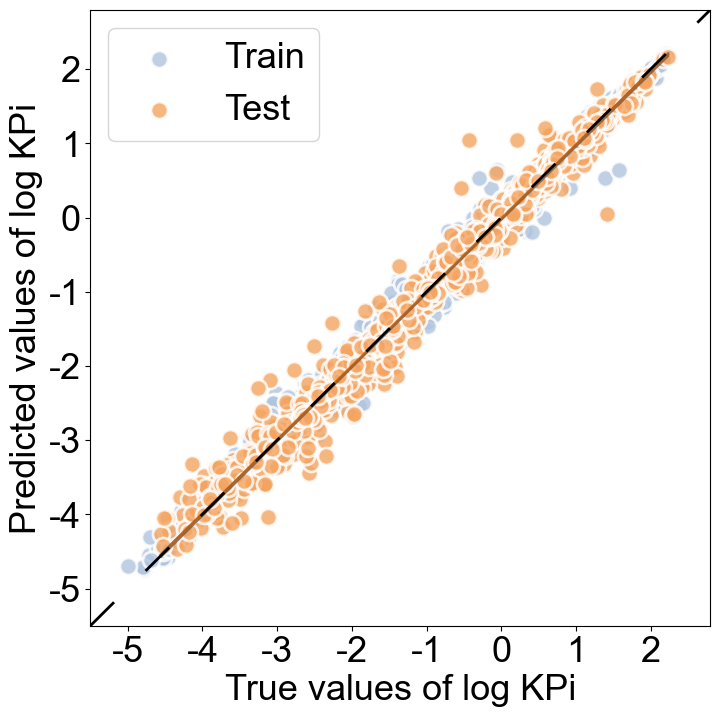

Slope_train: 0.9946900221664728
Intercept_train: -0.005106635009496818
Slope_test: 0.9937582052192973
Intercept_test: -0.014646420778122948


In [5]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress, t



df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'


y = df[target_column]
X = df.drop(columns=[target_column]) 

 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

XGBR = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.27, min_child_weight=1, seed=0, subsample=1, colsample_bytree=1, gamma=0, reg_alpha=0, reg_lambda=1)        
XGBR.fit(X_train, y_train)
 
  
y_train_pred = XGBR.predict(X_train)
y_test_pred = XGBR.predict(X_test)
 
 
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred) 
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)   
print(f"Mean Squared Error_train: {mse_train}")
print(f"Root Mean Squared Error_train: {rmse_train}") 
print(f"Mean Absolute Error_train: {mae_train}")
print(f"R^2 Score_train: {r2_train}")

mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"Mean Squared Error_test: {mse_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 
print(f"Mean Absolute Error_test: {mae_test}")
print(f"R^2 Score_test: {r2_test}")

def bootstrap_metrics(model, X, y, n_iterations=1000):
    
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    mse_scores = []
    
    y_pred = model.predict(X)
    
    r2_orig = r2_score(y, y_pred)
    mse_orig = mean_squared_error(y, y_pred)
    rmse_orig = np.sqrt(mse_orig)
    mae_orig = mean_absolute_error(y, y_pred)
    
    n = len(y)
    
    for _ in range(n_iterations):
        
        indices = np.random.choice(n, n, replace=True)
        
        if isinstance(X, pd.DataFrame):
            X_bs = X.iloc[indices]
        else:
            X_bs = X[indices]
        
        if isinstance(y, pd.Series):
            y_bs = y.iloc[indices]
        else:
            y_bs = y[indices]
        
        y_pred_bs = model.predict(X_bs)
        
        r2 = r2_score(y_bs, y_pred_bs)
        mse = mean_squared_error(y_bs, y_pred_bs)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_bs, y_pred_bs)
        
        r2_scores.append(r2)
        rmse_scores.append(rmse)
        mae_scores.append(mae)
        mse_scores.append(mse)
    
    def calc_ci(scores):
        lower = np.percentile(scores, 2.5)
        upper = np.percentile(scores, 97.5)
        return (lower, upper)
    
    return {
        'R2': {'value': r2_orig, 'ci': calc_ci(r2_scores)},
        'RMSE': {'value': rmse_orig, 'ci': calc_ci(rmse_scores)},
        'MAE': {'value': mae_orig, 'ci': calc_ci(mae_scores)},
        'MSE': {'value': mse_orig, 'ci': calc_ci(mse_scores)}
    }

train_metrics = bootstrap_metrics(XGBR, X_train, y_train, n_iterations=1000)

test_metrics = bootstrap_metrics(XGBR, X_test, y_test, n_iterations=1000)

def print_metrics(metrics, dataset_name):
    print(f"\n{dataset_name} (95% CI):")
    for metric, data in metrics.items():
        value = data['value']
        lower, upper = data['ci']
        print(f"{metric}: {value:.4f} (95% CI: [{lower:.4f}, {upper:.4f}])")

print_metrics(train_metrics, "train set")
print_metrics(test_metrics, "test set")


fig, ax = plt.subplots(figsize=(8, 8))  
  
ax.scatter(y_train, y_train_pred, label='Train', color='#B0C4DE', alpha=0.8, s=150, edgecolors='white', linewidths=2)  
  

ax.scatter(y_test, y_test_pred, label='Test', color='#F4A460', alpha=0.8, s=150, edgecolors='white', linewidths=2)  
  
  
ax.set_xlim(-5.5, 2.8)  
ax.set_ylim(-5.5, 2.8)
 
ax.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_xticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')  
ax.set_yticks([-5, -4, -3, -2, -1, 0, 1, 2])  
ax.set_yticklabels([-5, -4, -3, -2, -1, 0, 1, 2], fontsize=26, fontname='Arial')


ax.set_xlabel('True values of log KPi', fontsize=26, fontname = 'Arial')  
ax.set_ylabel('Predicted values of log KPi', fontsize=26, fontname = 'Arial')  
  

legend_props = matplotlib.font_manager.FontProperties(family= 'Arial', size=26)
ax.legend(prop=legend_props)

slope_train, intercept_train, r_value_train, p_value_train, std_err_train = linregress(y_train, y_train_pred) 
slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_test, y_test_pred)

x_sorted = np.sort(y_test)

y_fit_sorted = slope_test * x_sorted + intercept_test


residuals = y_test - y_test_pred
dof = len(y_test) - 2
s_err = np.sqrt(np.sum(residuals**2) / dof)


t_val = t.ppf(0.975, dof) 


conf_interval = t_val * s_err * np.sqrt(1/len(y_test) + (x_sorted - np.mean(y_test))**2 / np.sum((y_test - np.mean(y_test))**2))


lower_bound = y_fit_sorted - conf_interval
upper_bound = y_fit_sorted + conf_interval


ax.fill_between(x_sorted, lower_bound, upper_bound, color='#5F5F5F', alpha=0.7, label='95% Confidence Interval')


ax.plot(x_sorted, y_fit_sorted, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=2, label='Regression Line')

x_line = np.linspace(-5.5, 2.8, 100)
y_line = x_line

line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=2)
line.set_dashes([12, 16])

plt.show()

print (f"Slope_train: {slope_train}")
print (f"Intercept_train: {intercept_train}")
print (f"Slope_test: {slope_test}")
print (f"Intercept_test: {intercept_test}")

R^2 Score_test: 0.9860020200886948
Root Mean Squared Error_test: 0.20242065908475762


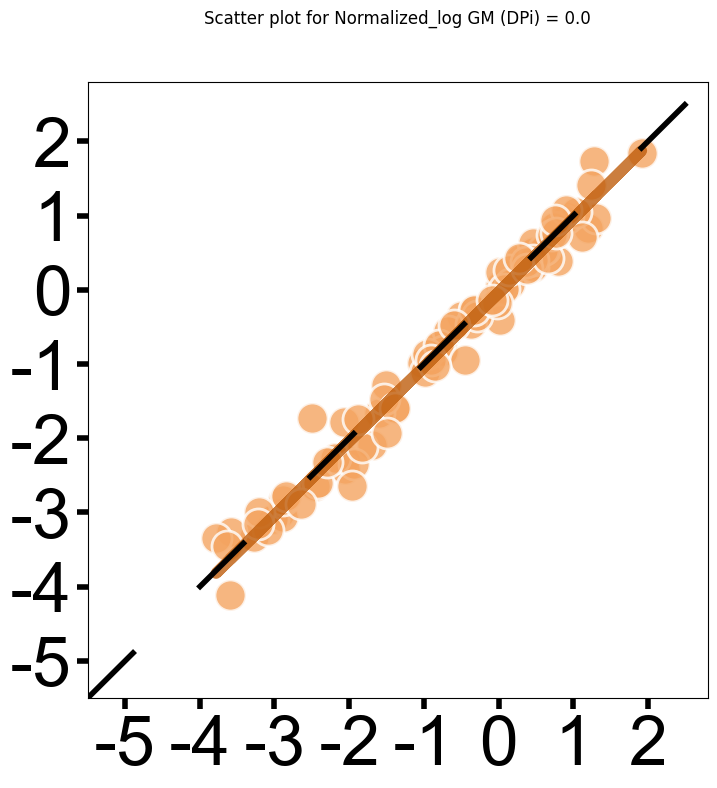

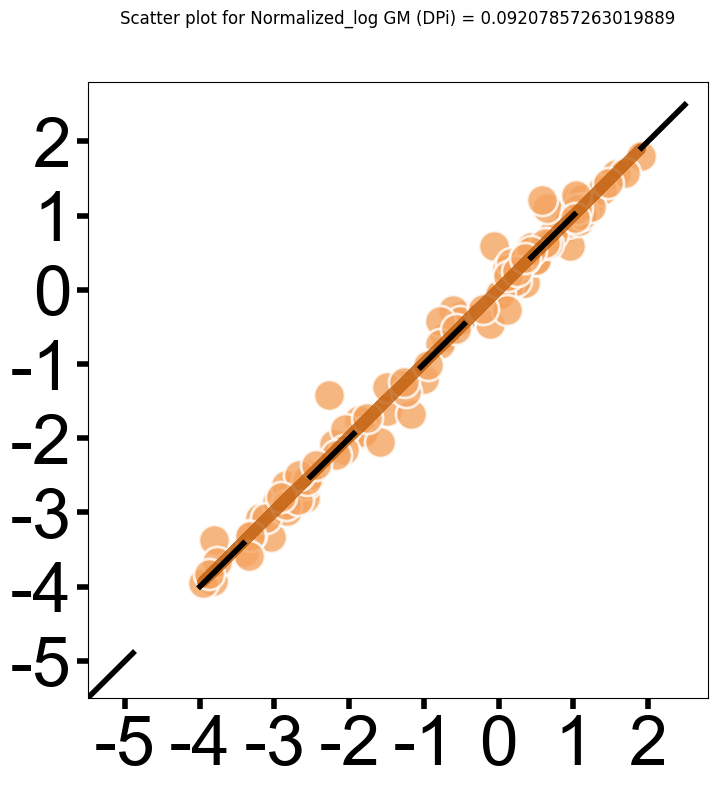

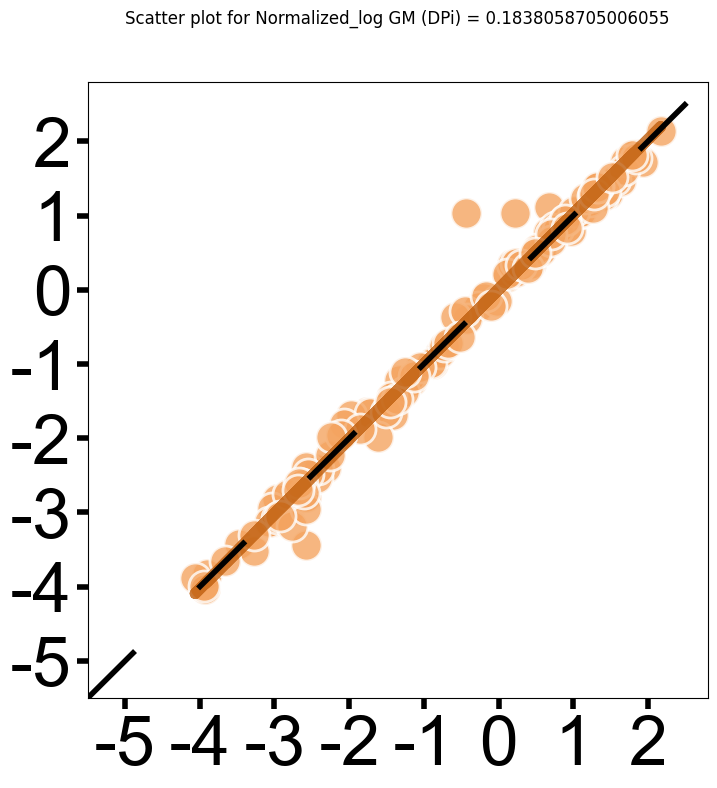

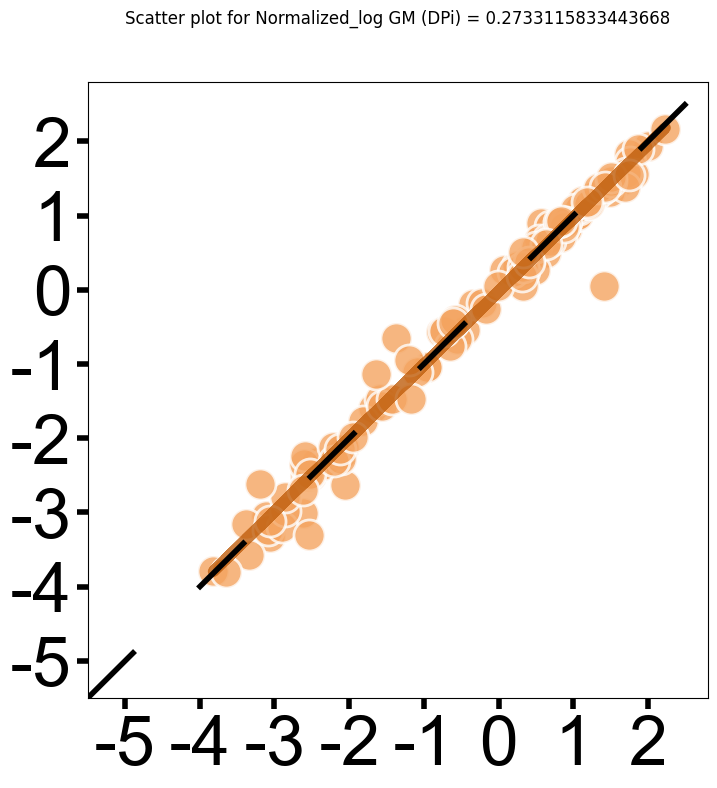

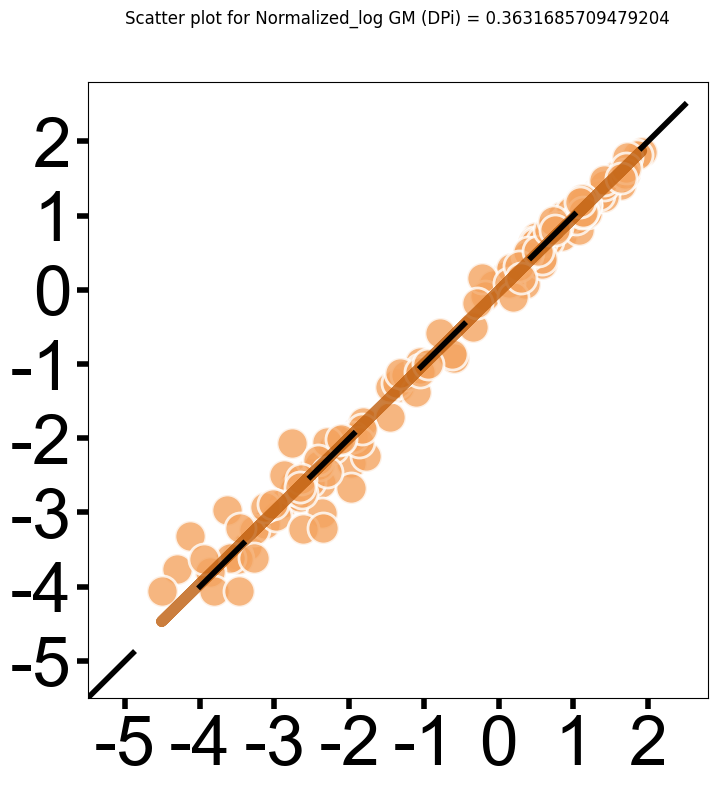

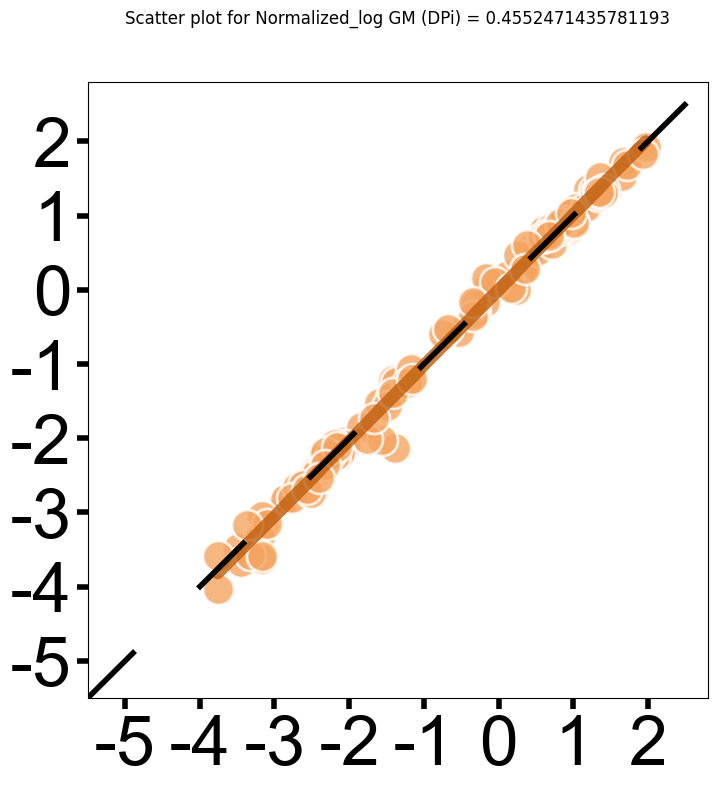

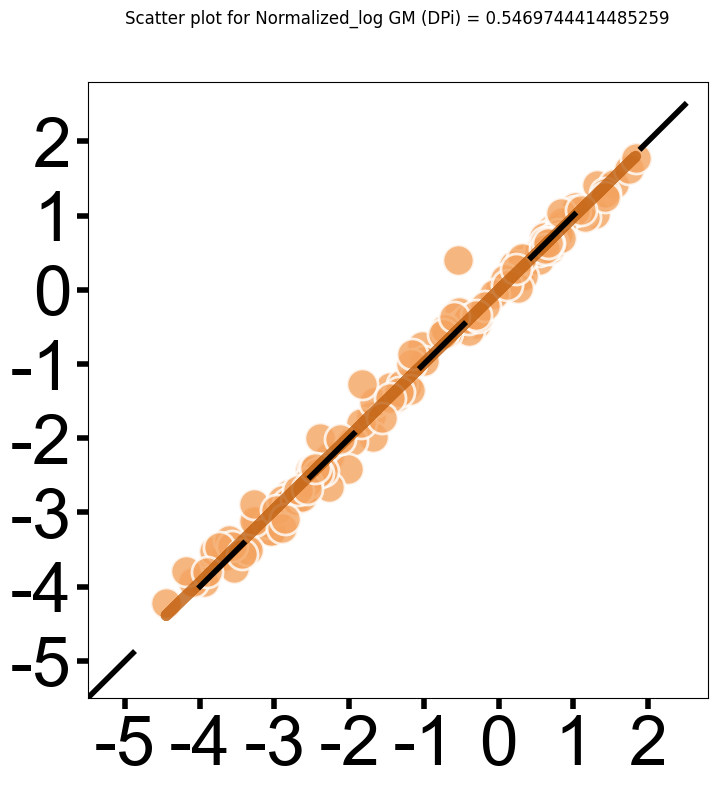

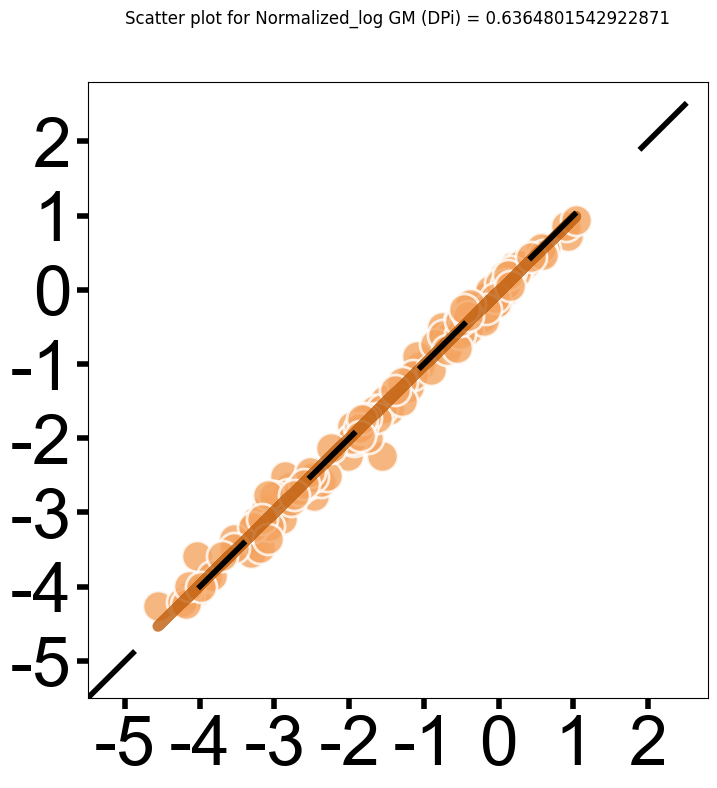

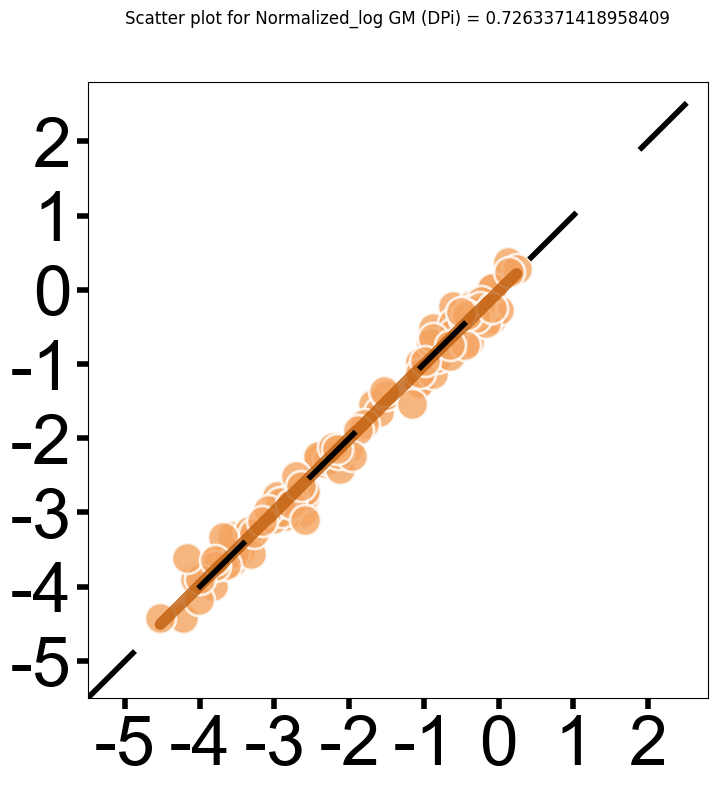

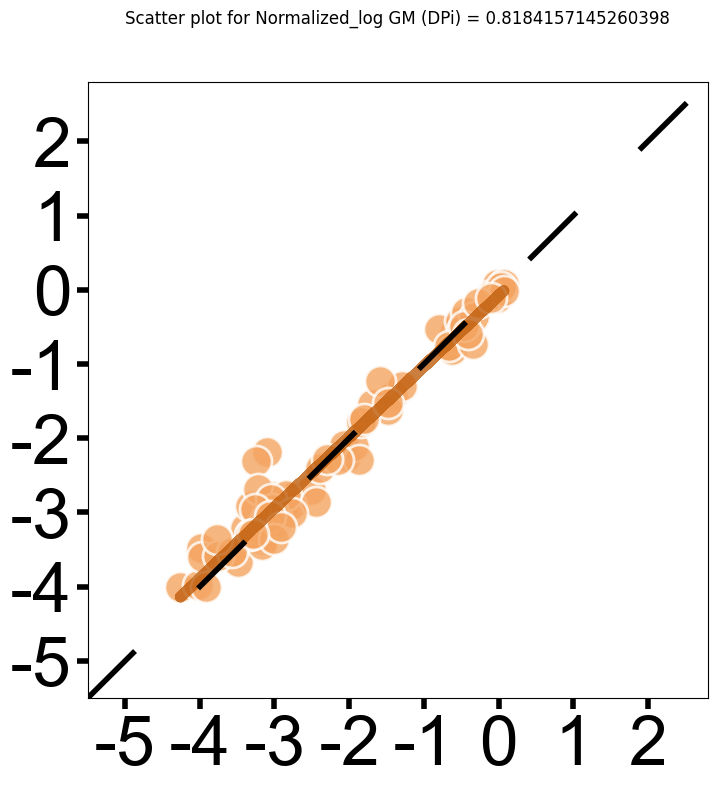

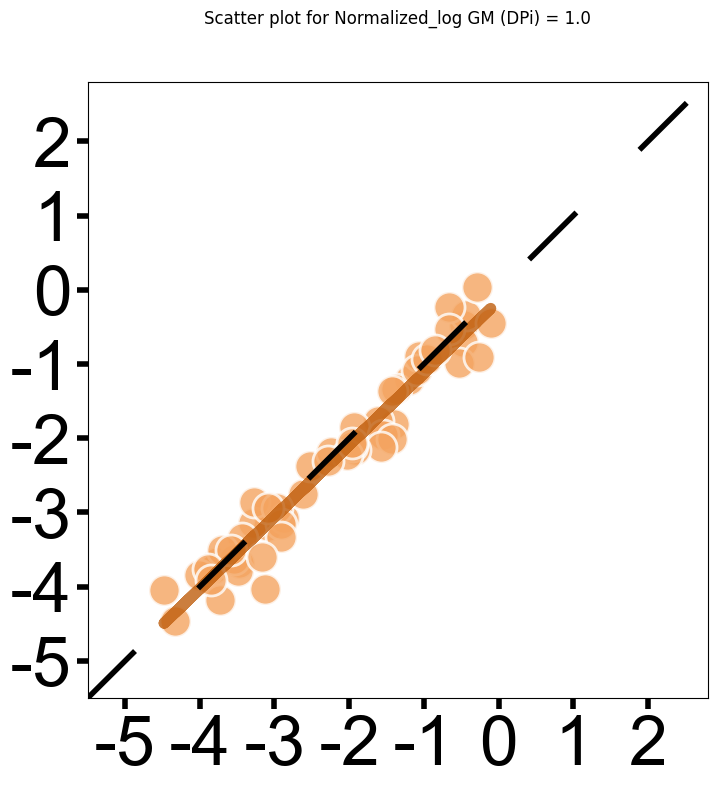

XGB For Normalized_log GM (DPi) = 0.0, R² = 0.9753959861873993, RMSE = 0.23201080554035203
XGB For Normalized_log GM (DPi) = 0.09207857263019889, R² = 0.9853640552071306, RMSE = 0.1995202644682027
XGB For Normalized_log GM (DPi) = 0.1838058705006055, R² = 0.984979194346522, RMSE = 0.2119930664525753
XGB For Normalized_log GM (DPi) = 0.2733115833443668, R² = 0.9830559009310867, RMSE = 0.21598756610642458
XGB For Normalized_log GM (DPi) = 0.3631685709479204, R² = 0.9844471385695059, RMSE = 0.2277001567080099
XGB For Normalized_log GM (DPi) = 0.4552471435781193, R² = 0.992654323364172, RMSE = 0.14332598402180097
XGB For Normalized_log GM (DPi) = 0.5469744414485259, R² = 0.9902376293918226, RMSE = 0.17017626653896928
XGB For Normalized_log GM (DPi) = 0.6364801542922871, R² = 0.9900822829810634, RMSE = 0.14725004030570635
XGB For Normalized_log GM (DPi) = 0.7263371418958409, R² = 0.9817734654880741, RMSE = 0.1805236581168879
XGB For Normalized_log GM (DPi) = 0.8184157145260398, R² = 0.96411

In [3]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'

 
y = df[target_column]
X = df.drop(columns=[target_column]) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
particle_size = X_test['log GM (DPi)']

XGBR = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.27, min_child_weight=1, seed=0, subsample=1, colsample_bytree=1, gamma=0, reg_alpha=0, reg_lambda=1)        
XGBR.fit(X_train, y_train)
 
 
y_train_pred = XGBR.predict(X_train)
y_test_pred = XGBR.predict(X_test)

mse_test = mean_squared_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"R^2 Score_test: {r2_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 

 
df_1 = pd.DataFrame({'particle size': particle_size, 'y_test': y_test, 'y_test_pred': y_test_pred})

metrics = {}  
  
  
for value in np.unique(particle_size):  
    subset = df_1[df_1['particle size'] == value]  
    y_true_subset = subset['y_test'].values  
    y_pred_subset = subset['y_test_pred'].values  
      
    
    r2 = r2_score(y_true_subset, y_pred_subset)  
      
     
    rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))  
      
     
    metrics[value] = {'r2': r2, 'rmse': rmse}  
      
      
    plt.figure(figsize=(8, 8)) 
     
    plt.scatter(y_true_subset, y_pred_subset, color='#F4A460', alpha=0.8, s=500, edgecolors='white', linewidths=2)
    plt.xlim(-5.5, 2.8)
    plt.ylim(-5.5, 2.8)
    
     
    plt.xticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
  
     
    plt.yticks(ticks=[-5, -4, -3, -2, -1, 0, 1, 2], labels=[-5, -4, -3, -2, -1, 0, 1, 2], fontdict={'family': 'Arial', 'size': 50})  
    
      
    plt.tick_params(axis='both', which='major', length=8, width=4)

    slope_test, intercept_test, r_value_test, p_value_test, std_err_test = linregress(y_true_subset, y_pred_subset)
    line_test_fit = plt.plot(y_true_subset, slope_test * y_true_subset + intercept_test, color='#BF5E0D', linestyle='solid', alpha=0.8, linewidth=8)
    
    
    x_line = np.linspace(-5.5, 2.8, 100)
    y_line = x_line
    
    line, =plt.plot(x_line, y_line, color='#000000', linestyle='--', linewidth=4)
    line.set_dashes([12, 16])
    
    plt.title(f'Scatter plot for Normalized_log GM (DPi) = {value}', loc='center', pad=20, y=1.05) 
    
    plt.show()  
  
 
for value, metric in metrics.items():  
    print(f'XGB For Normalized_log GM (DPi) = {value}, R² = {metric["r2"]}, RMSE = {metric["rmse"]}')


In [1]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.legend as legend
from scipy.stats import linregress


df = pd.read_excel('preprocessed_input_data_6_features.xlsx')


target_column = 'log KPi'

 
y = df[target_column]
X = df.drop(columns=[target_column]) 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
particle_size = X['log GM (DPi)']

XGBR = XGBRegressor(n_estimators=400, max_depth=5, learning_rate=0.27, min_child_weight=1, seed=0, subsample=1, colsample_bytree=1, gamma=0, reg_alpha=0, reg_lambda=1)        
XGBR.fit(X_train, y_train)
 
 
y_train_pred = XGBR.predict(X_train)
y_test_pred = XGBR.predict(X_test)

y_pred = XGBR.predict(X)

mse_test = mean_squared_error(y_test, y_test_pred) 
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)   
print(f"R^2 Score_test: {r2_test}")
print(f"Root Mean Squared Error_test: {rmse_test}") 

 
df_1 = pd.DataFrame({'particle size': particle_size, 'y': y, 'y_pred': y_pred})

metrics = {}  
  
  
for value in np.unique(particle_size):  
    subset = df_1[df_1['particle size'] == value]  
    y_true_subset = subset['y'].values  
    y_pred_subset = subset['y_pred'].values

    
    r2 = r2_score(y_true_subset, y_pred_subset)  
      
     
    rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))  
      
     
    metrics[value] = {'r2': r2, 'rmse': rmse}  
  
  
 
for value, metric in metrics.items():  
    print(f'XGB For Normalized_log GM (DPi) (all data) = {value}, R² = {metric["r2"]}, RMSE = {metric["rmse"]}')

R^2 Score_test: 0.9860020200886948
Root Mean Squared Error_test: 0.20242065908475762
XGB For Normalized_log GM (DPi) (all data) = 0.0, R² = 0.9898391758392988, RMSE = 0.14456164213450853
XGB For Normalized_log GM (DPi) (all data) = 0.09207857263019889, R² = 0.9952650278291927, RMSE = 0.1106352109541467
XGB For Normalized_log GM (DPi) (all data) = 0.1838058705006055, R² = 0.994762739668173, RMSE = 0.12464925379999796
XGB For Normalized_log GM (DPi) (all data) = 0.2733115833443668, R² = 0.9948191409883084, RMSE = 0.12526457730579993
XGB For Normalized_log GM (DPi) (all data) = 0.3631685709479204, R² = 0.9938016772253477, RMSE = 0.1370882640088202
XGB For Normalized_log GM (DPi) (all data) = 0.4552471435781193, R² = 0.9956241822902102, RMSE = 0.1123275223985903
XGB For Normalized_log GM (DPi) (all data) = 0.5469744414485259, R² = 0.9950265750941999, RMSE = 0.11381489925778505
XGB For Normalized_log GM (DPi) (all data) = 0.6364801542922871, R² = 0.9948436561284282, RMSE = 0.113404000603181